# Aim : Develop a machine learning model that can classify the images into the predefined 3 labels.

# This notebook includes :
# Import Libraries
# Load Dataset
# EDA Part
# Data Preprocessing
# Model Evulation

# Import Libraries

In [ ]:
# 🔹 Basic Libraries
import os
import numpy as np

# 🔹 Data Visualization
import matplotlib.pyplot as plt

# 🔹 Image Processing
from PIL import Image
from tensorflow.keras.preprocessing import image

# 🔹 Deep Learning (CNN)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2

# 🔹 Data Preprocessing & Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 🔹 Model Evaluation
from sklearn.metrics import classification_report, confusion_matrix

# Dataset path

In [ ]:
train_dir = r"C:\Users\Rahul mahamuni\Downloads\Bin-dataset-3\Data\train"
val_dir = r"C:\Users\Rahul mahamuni\Downloads\Bin-dataset-3\Data\validation"
test_dir = r"C:\Users\Rahul mahamuni\Downloads\Bin-dataset-3\Data\test"

In [ ]:
base_dir = "Bin-dataset-3/Data"   # update if needed
# Remove Invalid + Corrupted Files
valid_extensions = ('.jpg', '.jpeg', '.png')

removed_files = 0

for root, dirs, files in os.walk(base_dir):
    for file in files:
        file_path = os.path.join(root, file)

        # ❌ Remove non-image files
        if not file.lower().endswith(valid_extensions):
            os.remove(file_path)
            removed_files += 1
            print("Removed invalid:", file_path)
            continue

        # ❌ Remove corrupted images
        try:
            img = Image.open(file_path)
            img.verify()
        except:
            os.remove(file_path)
            removed_files += 1
            print("Removed corrupt:", file_path)

print("\nTotal removed files:", removed_files)


Total removed files: 0


In [ ]:
# Remove Duplicate images
hashes = {}
duplicates = 0

for root, dirs, files in os.walk(base_dir):
    for file in files:
        file_path = os.path.join(root, file)

        try:
            with open(file_path, 'rb') as f:
                filehash = hashlib.md5(f.read()).hexdigest()

            if filehash in hashes:
                os.remove(file_path)
                duplicates += 1
                print("Removed duplicate:", file_path)
            else:
                hashes[filehash] = file_path
        except:
            continue

print("\nTotal duplicates removed:", duplicates)


Total duplicates removed: 0


In [ ]:
# Resize Images
for root, dirs, files in os.walk(base_dir):
    for file in files:
        file_path = os.path.join(root, file)

        try:
            img = Image.open(file_path).convert("RGB")
            img = img.resize((224,224))
            img.save(file_path)
        except:
            continue

print("All images resized to 224x224")

All images resized to 224x224


# Check Total Images in Dataset

In [ ]:
def count_images(folder):
    total = 0
    for category in os.listdir(folder):
        path = os.path.join(folder, category)
        total += len(os.listdir(path))
    return total

print("Train Images:", count_images(train_dir))
print("Validation Images:", count_images(val_dir))
print("Test Images:", count_images(test_dir))

Train Images: 1035
Validation Images: 133
Test Images: 128


# EDA Part : EDA in image classification involves analyzing class distribution, visualizing images, checking image properties, and preparing data for model training.

Class Distribution:
angular_leaf_spot : 345
bean_rust : 348
healthy : 342


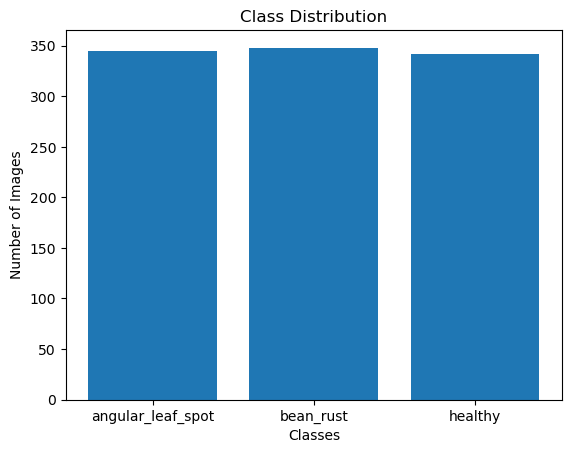

In [ ]:
# Classes Distribution
classes = []
counts = []

for category in os.listdir(train_dir):
    path = os.path.join(train_dir, category)
    classes.append(category)
    counts.append(len(os.listdir(path)))

print("Class Distribution:")
for c, count in zip(classes, counts):
    print(c, ":", count)

plt.bar(classes, counts)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

# Insights : The dataset is well-balanced, as all three classes have almost equal number of images.

# This reduces the risk of model bias toward any specific class.

# A balanced dataset helps in achieving more reliable and fair model performance.

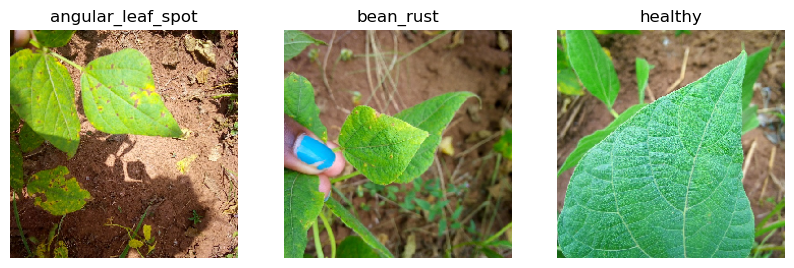

In [ ]:
# Show Sample Images
plt.figure(figsize=(10,5))

for i, category in enumerate(classes):
    img_path = os.path.join(train_dir, category, os.listdir(os.path.join(train_dir, category))[0])

    img = image.load_img(img_path, target_size=(224,224))

    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(category)
    plt.axis("off")

plt.show()

# Insights : The images clearly show visual differences between classes, where diseased leaves (angular_leaf_spot, bean_rust) have spots/discoloration, while healthy leaves are uniformly green.

# Disease classes have distinct patterns and textures, which helps the model learn to differentiate them.

# This variation in appearance makes the dataset suitable for image classification tasks.

In [ ]:
# Images Size Check
for category in classes:
    path = os.path.join(train_dir, category)
    img_path = os.path.join(path, os.listdir(path)[0])

    img = Image.open(img_path)
    print(category, "image size:", img.size)

angular_leaf_spot image size: (500, 500)
bean_rust image size: (500, 500)
healthy image size: (500, 500)


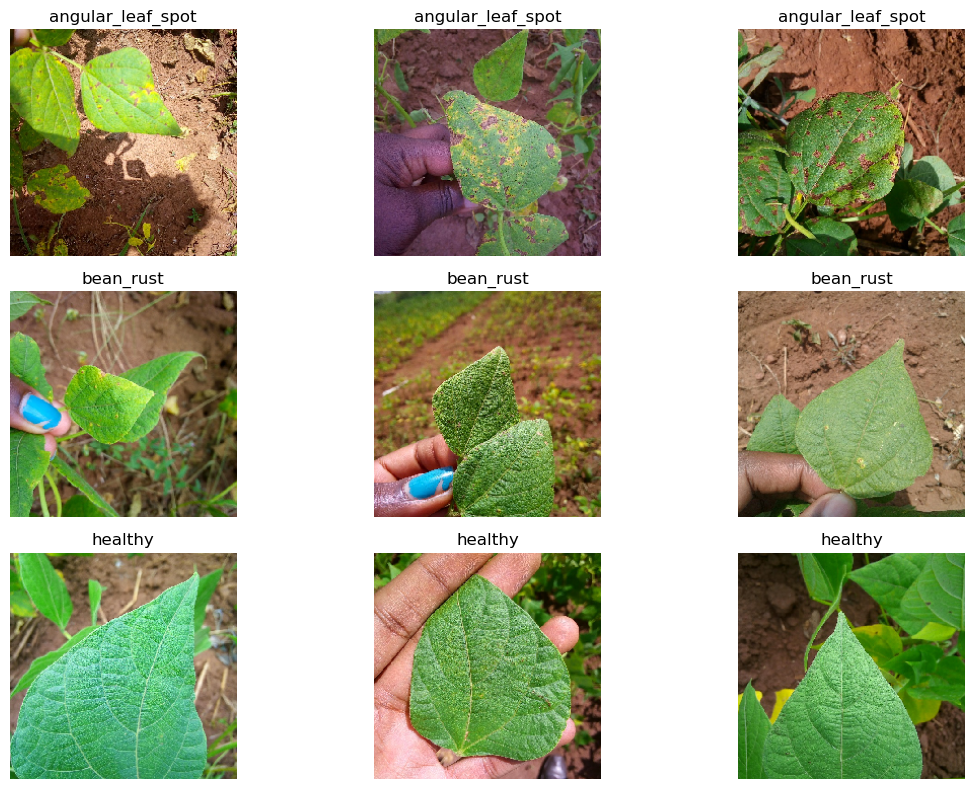

In [ ]:
# Show Mulitple Images Per class
plt.figure(figsize=(12,8))

for i, category in enumerate(classes):
    path = os.path.join(train_dir, category)
    images = os.listdir(path)[:3]  # first 3 images

    for j, img_name in enumerate(images):
        img_path = os.path.join(path, img_name)
        img = image.load_img(img_path, target_size=(224,224))

        plt.subplot(len(classes), 3, i*3 + j + 1)
        plt.imshow(img)
        plt.title(category)
        plt.axis("off")

plt.tight_layout()
plt.show()

# Insights : The dataset contains multiple classes with distinct visual patterns, such as different types of leaf diseases, making it suitable for multi-class classification.

# Each class shows variation in color, texture, and spot patterns, helping the model learn meaningful differences between categories.

# There is also intra-class variation (different images within the same class), which improves the model’s ability to generalize better.

In [ ]:
# Percentage distribution of  classes
total = sum(counts)

for c, count in zip(classes, counts):
    print(f"{c}: {round((count/total)*100,2)}%")

angular_leaf_spot: 33.33%
bean_rust: 33.62%
healthy: 33.04%


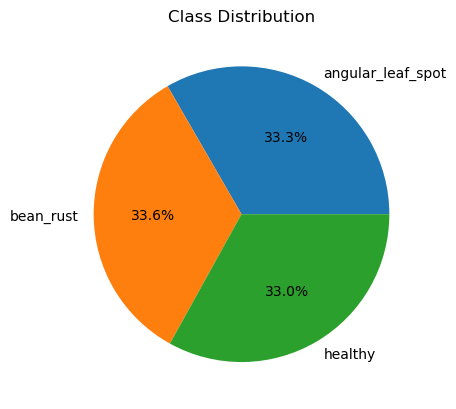

In [ ]:
# Pie chart for class distribution
plt.pie(counts, labels=classes, autopct='%1.1f%%')
plt.title("Class Distribution")
plt.show()

# Insights : The dataset shows a nearly equal distribution across all classes, ensuring a balanced dataset that supports unbiased model training and improved classification performance

In [ ]:
# Skip corrputed images
from PIL import Image, UnidentifiedImageError

widths = []
heights = []

for category in classes:
    path = os.path.join(train_dir, category)

    for img_name in os.listdir(path)[:50]:
        img_path = os.path.join(path, img_name)

        try:
            img = Image.open(img_path)
            widths.append(img.size[0])
            heights.append(img.size[1])
        except UnidentifiedImageError:
            print("Skipping invalid image:", img_path)
            continue

print("Avg Width:", np.mean(widths))
print("Avg Height:", np.mean(heights))

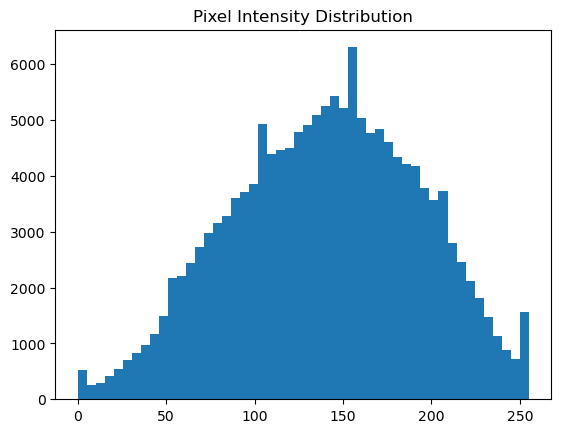

In [ ]:
# Pixel Intensity Distribution
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

plt.hist(img_array.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()

# Insights : The pixel intensity distribution is well spread across the range (0–255), indicating good variation in brightness and contrast.

# Most values are concentrated in the mid-range, suggesting images are neither too dark nor too bright.

# This balanced distribution helps the model learn features effectively without bias toward extreme lighting conditions.

# Data Preprocessing

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,       # Preprocessing (Normalization)
    rotation_range=20,    # Augmentation (rotate images)
    zoom_range=0.2,       # Augmentation (zoom images)
    horizontal_flip=True  # Augmentation (flip images)
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Normalization using rescaling (1/255)
# Data augmentation (rotation, zoom, flipping) applied only on training data

# Load Dataset

In [ ]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1034 images belonging to 3 classes.
Found 133 images belonging to 3 classes.
Found 128 images belonging to 3 classes.


# Transfer Learning Model(MobileNetV2)

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(3, activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Train Model (Initial Training)
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.6809 - loss: 0.7901 - val_accuracy: 0.7820 - val_loss: 0.4350
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.8056 - loss: 0.4770 - val_accuracy: 0.8647 - val_loss: 0.3450
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.8482 - loss: 0.3928 - val_accuracy: 0.8571 - val_loss: 0.3005
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.8598 - loss: 0.3369 - val_accuracy: 0.8872 - val_loss: 0.2620
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.8714 - loss: 0.3088 - val_accuracy: 0.8271 - val_loss: 0.3465
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.8810 - loss: 0.3067 - val_accuracy: 0.9023 - val_loss: 0.2342
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.8839 - loss: 0.2921 - val_accuracy: 0.8947 - val_loss: 0.2584
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.9120 - loss: 0.2391 - val_accuracy: 0.8722 - val_loss:

In [ ]:
# Save model as model.pkl and features.pkl
import joblib

# 🔹 Save model
joblib.dump(model, "model.pkl")

# 🔹 Save class labels (recommended: dictionary)
joblib.dump(train_data.class_indices, "features.pkl")

print("model.pkl and features.pkl saved successfully!")

model.pkl and features.pkl saved successfully!


In [ ]:
# Load model.pkl and features.pkl
import joblib

# Load model
model = joblib.load("model.pkl")

# Load class mapping
class_indices = joblib.load("features.pkl")

# Reverse mapping (index → label)
labels = {v: k for k, v in class_indices.items()}

print("Loaded successfully!")

In [ ]:
# Evulated Model
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 725ms/step - accuracy: 0.9141 - loss: 0.2377
Test Accuracy: 0.9140625


# Results

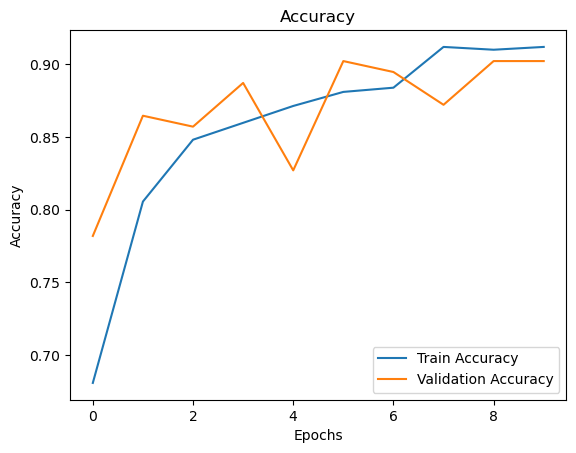

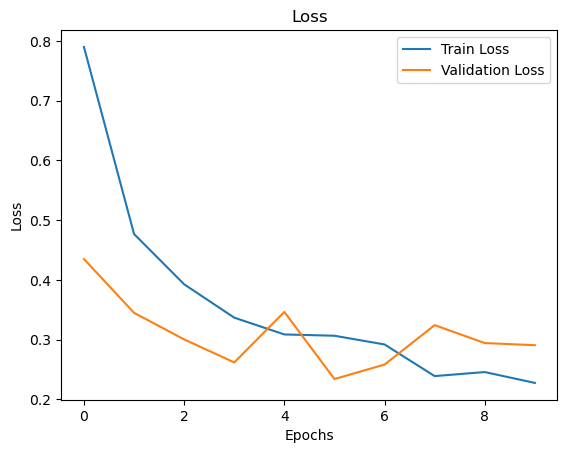

In [ ]:
# Plot Accuracy and Loss
# Accuracy Plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss Plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# Insights : The model shows strong learning with training accuracy reaching 91%, but the validation curves are highly unstable with significant performance spikes and dips.

# Optimal generalization occurs around Epoch 10, after which the model begins to plateau and show early signs of overfitting as the validation loss fails to improve further.

# Confusion Martix and Report

In [ ]:
predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)

print("Confusion Matrix:")
print(confusion_matrix(test_data.classes, y_pred))

print("\nClassification Report:")
print(classification_report(test_data.classes, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 756ms/step
Confusion Matrix:
[[38  5  0]
 [ 4 38  1]
 [ 0  1 41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89        43
           1       0.86      0.88      0.87        43
           2       0.98      0.98      0.98        42

    accuracy                           0.91       128
   macro avg       0.91      0.91      0.91       128
weighted avg       0.91      0.91      0.91       128



# Analysis :
# The model performs exceptionally well on Class 2 with near-perfect scores, while showing slight confusion between Class 0 and Class 1, where 9 instances were misclassified across the two categories.

# Overall, the model is highly balanced and reliable with a 91% accuracy across 128 samples, as reflected by the matching macro and weighted F1-scores.

In [ ]:
# Save Model
model.save("final_model.keras")

# Key Insights the report
# The model demonstrates strong classification performance with good generalization ability, supported by balanced data, effective preprocessing, and the use of transfer learning techniques, along with data augmentation strategies that further enhanced accuracy and robustness across unseen data.

# Challenges faced during Project :
# The project faced challenges related to data quality, preprocessing, model tuning, and deployment, which were addressed through systematic data cleaning, augmentation, and optimization techniques. Additional efforts were made to handle corrupted and inconsistent image data, carefully tune hyperparameters, and implement  strategies to improve model performance. Deployment challenges were resolved by integrating the trained model into a user-friendly interface, ensuring smooth prediction and efficient real-time usage.